# Customer Churn -- Analysis & EDA

This notebook is the exploratory / reporting layer. All reusable logic (data loading, feature engineering, model training, survival analysis) lives in the `src/` package and is imported here rather than duplicated.

In [ ]:
%pip install -q -r requirements.txt


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))
from src import classifiers, data, explain, features, survival


Matplotlib is building the font cache; this may take a moment.


## Data loading

In [2]:
df = data.load_data()
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerId          10000 non-null  int64  
 1   Surname             10000 non-null  object 
 2   CreditScore         10000 non-null  int64  
 3   Geography           10000 non-null  object 
 4   Gender              10000 non-null  object 
 5   Age                 10000 non-null  int64  
 6   Tenure              10000 non-null  int64  
 7   Balance             10000 non-null  float64
 8   NumOfProducts       10000 non-null  int64  
 9   HasCrCard           10000 non-null  int64  
 10  IsActiveMember      10000 non-null  int64  
 11  EstimatedSalary     10000 non-null  float64
 12  Exited              10000 non-null  int64  
 13  Complain            10000 non-null  int64  
 14  Satisfaction Score  10000 non-null  int64  
 15  Card Type           10000 non-null  object 
 16  Point

In [4]:
df.isnull().sum()

CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [5]:
df[df.duplicated()]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned


## EDA

In [6]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [7]:
corr = df.drop(columns=['Surname', 'Geography', 'Gender']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlation')
plt.show()

ValueError: could not convert string to float: 'DIAMOND'

Balance, Age, IsActiveMember and NumOfProducts show the strongest correlation with churn (`Exited`).

### Target distribution

Exited
0    7962
1    2038
Name: count, dtype: int64
Churn rate: 20.38%


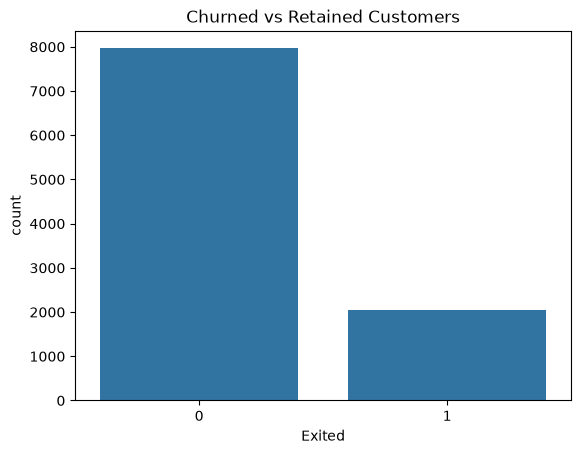

In [8]:
churn_counts = df['Exited'].value_counts()
churn_rate = df['Exited'].mean()
print(churn_counts)
print(f'Churn rate: {churn_rate:.2%}')

sns.countplot(data=df, x='Exited')
plt.title('Churned vs Retained Customers')
plt.show()

### Numeric feature distributions

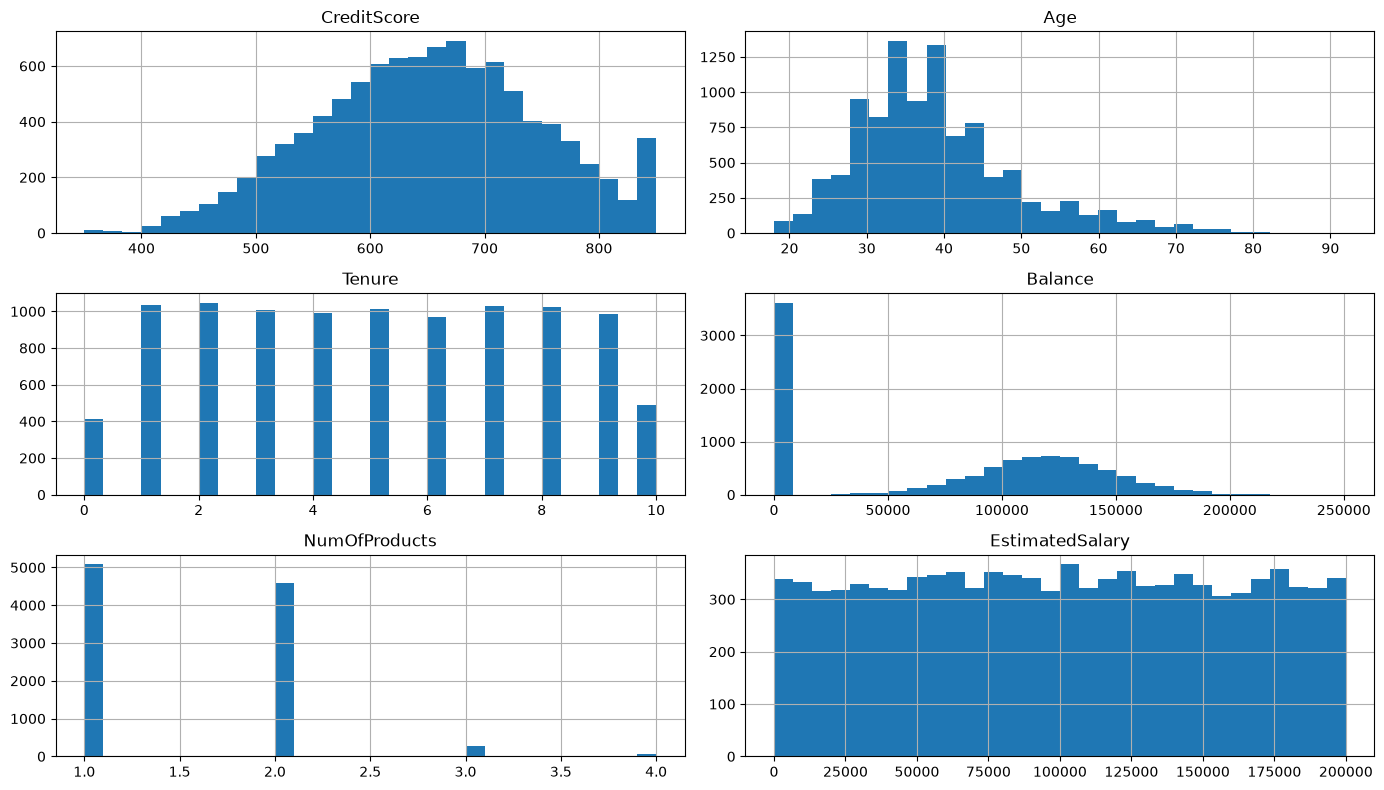

In [9]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
df[numeric_cols].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()

### Churn rate by categorical features

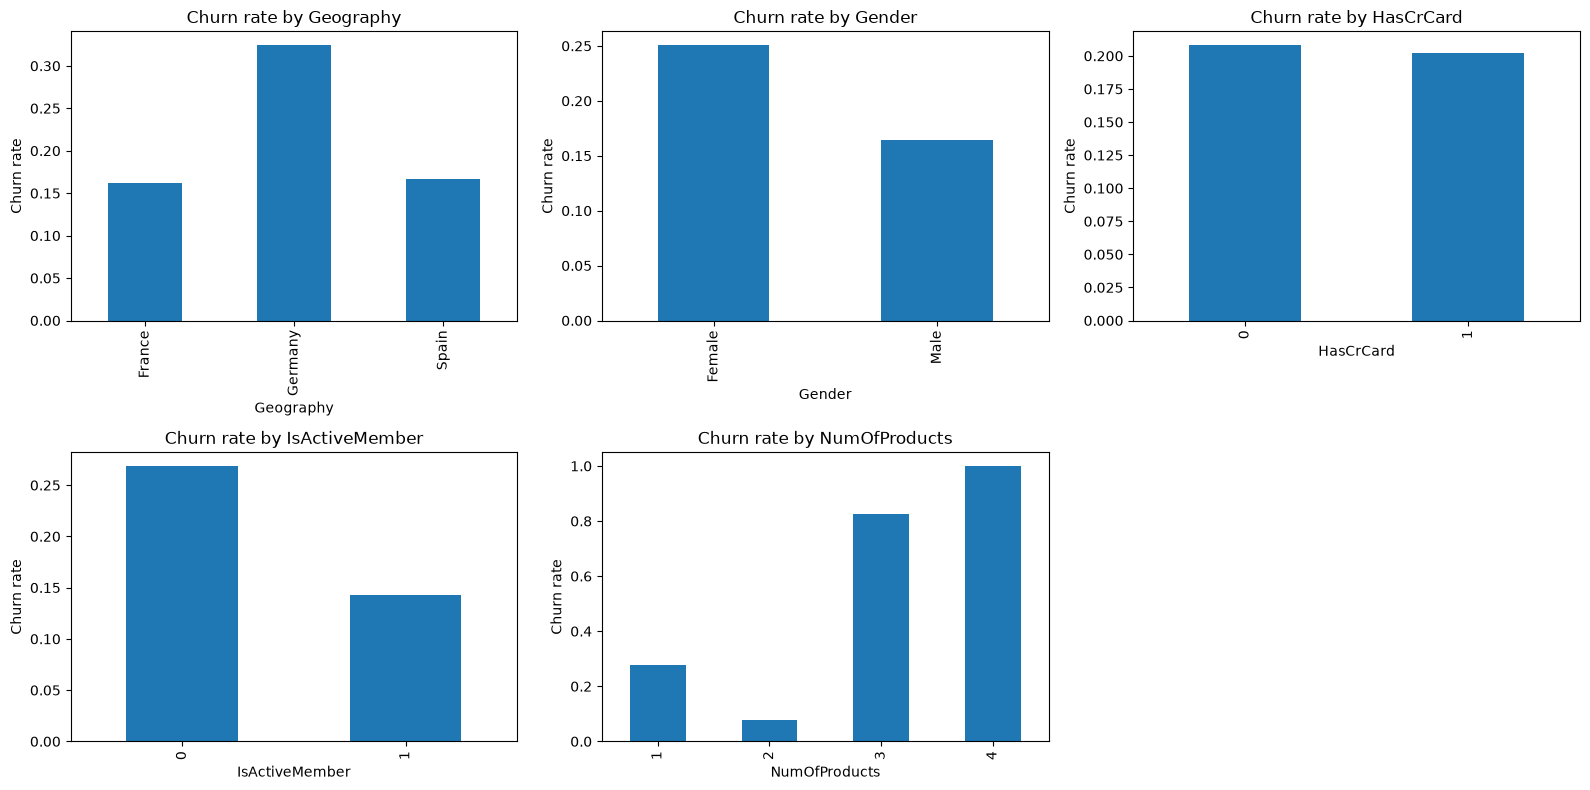

In [10]:
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, categorical_cols):
    df.groupby(col)['Exited'].mean().plot(kind='bar', ax=ax)
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

### Numeric feature spread by churn status

Boxplots highlight which features separate churners from retained customers, and surface outliers within each group.

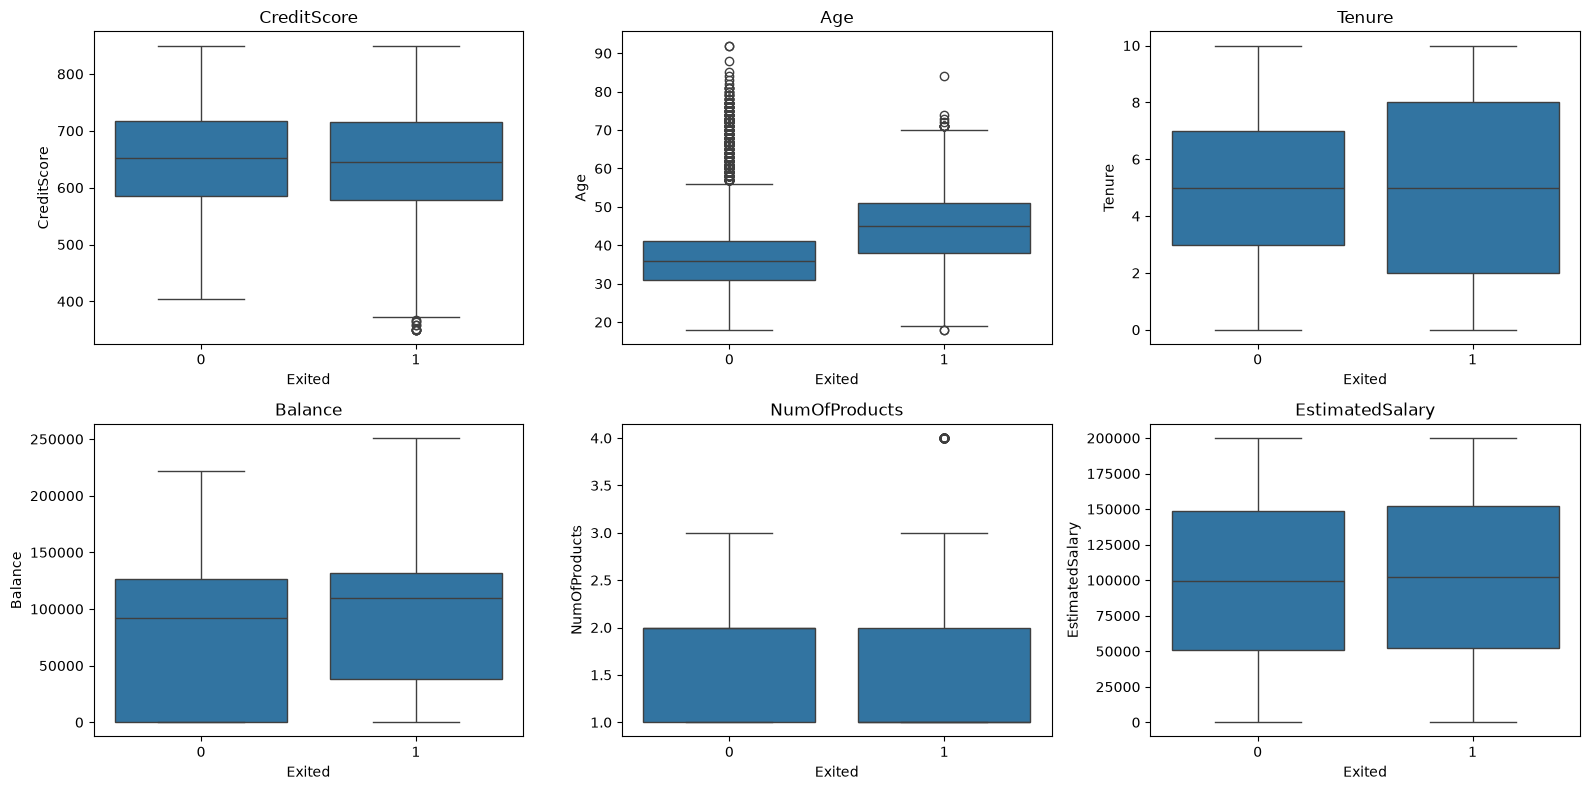

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=df, x='Exited', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Pairwise relationships

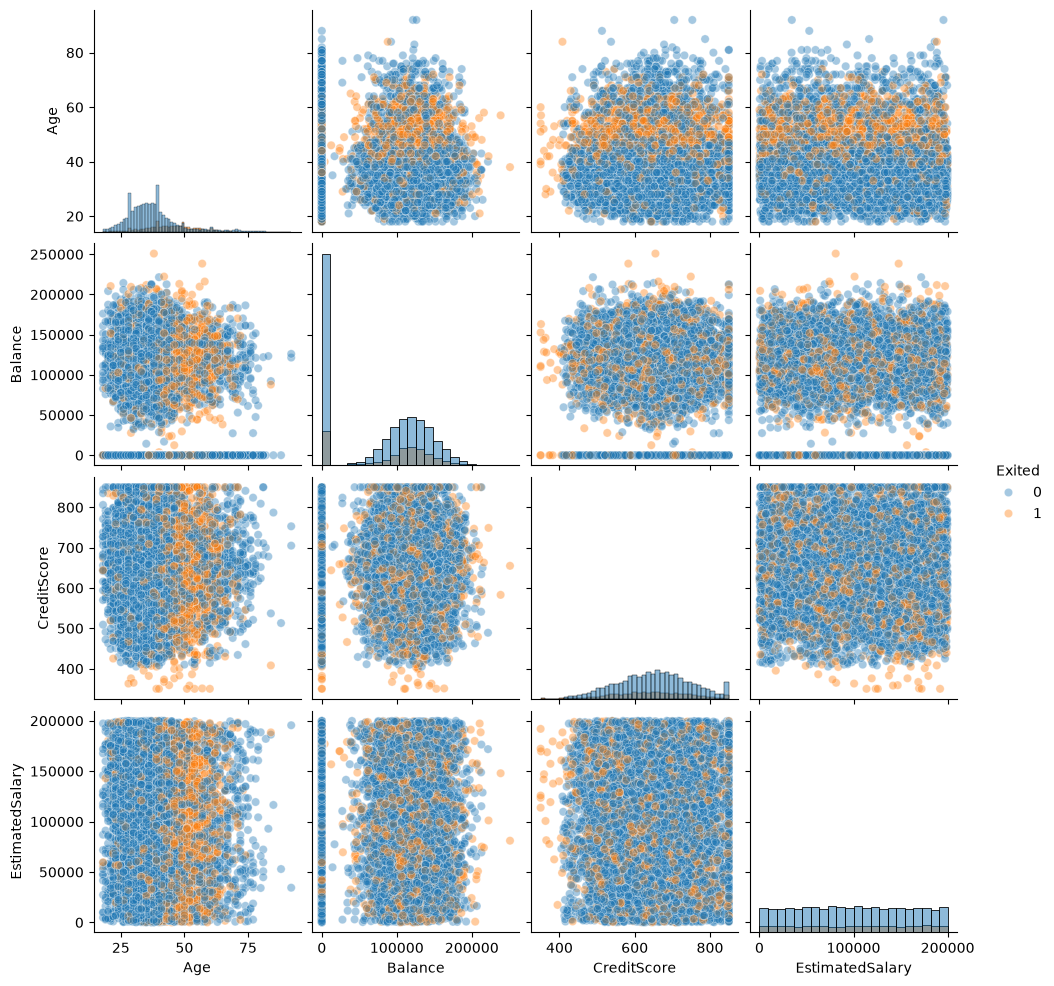

In [12]:
sns.pairplot(df, vars=['Age', 'Balance', 'CreditScore', 'EstimatedSalary'], hue='Exited', diag_kind='hist', plot_kws={'alpha': 0.4})
plt.show()

## Feature engineering

In [13]:
df_encoded = features.encode_features(df)
df_encoded.head()

,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Geography_Germany,Geography_Spain
0,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,False,False
1,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,False,True
2,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,False,False
3,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,False,False
4,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,False,True


In [14]:
X, y = features.split_features_target(df_encoded)
X_train, X_test, y_train, y_test = features.train_test_split_data(X, y)
X_train_scaled, X_test_scaled, scaler = features.scale_features(X_train, X_test)

## Modelling

### Random Forest

In [15]:
rf_model = classifiers.train_random_forest(X_train_scaled, y_train)
rf_result = classifiers.evaluate('RandomForest', y_test, rf_model.predict(X_test_scaled))
print(rf_result.confusion_matrix)
print(rf_result.classification_report)
print(f'Accuracy: {rf_result.accuracy:.4f}')

[[1547   60]
 [ 207  186]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000

Accuracy: 0.8665


#### Feature importance

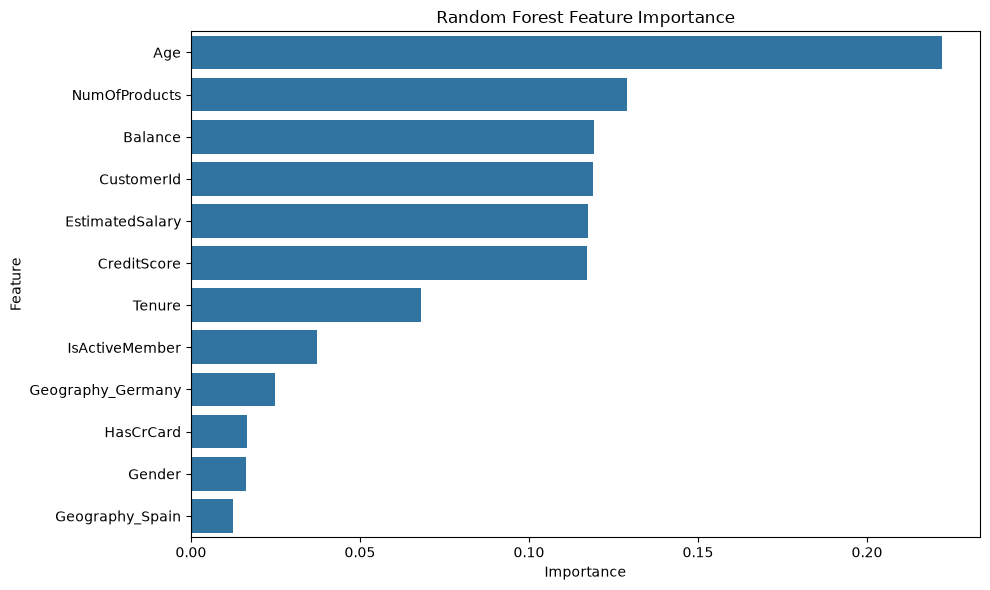

In [16]:
imp = classifiers.feature_importance(rf_model, features.FEATURES)
plt.figure(figsize=(10, 6))
sns.barplot(data=imp, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

#### SHAP explainability

In [17]:
shap_values = explain.tree_shap_values(rf_model, X_test_scaled)
shap_values

c:\Users\HP\Desktop\Churn_Prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


array([[[-6.37048122e-04,  6.37048122e-04],
        [ 7.48970587e-03, -7.48970587e-03],
        [ 2.57444331e-02, -2.57444331e-02],
        ...,
        [ 8.60536176e-04, -8.60536176e-04],
        [-4.27869821e-02,  4.27869821e-02],
        [-2.29738848e-05,  2.29738848e-05]],

       [[ 9.40644620e-03, -9.40644620e-03],
        [ 6.55589228e-03, -6.55589228e-03],
        [ 1.71259600e-02, -1.71259600e-02],
        ...,
        [ 8.86445520e-03, -8.86445520e-03],
        [ 1.33522856e-02, -1.33522856e-02],
        [-7.95120179e-05,  7.95120179e-05]],

       [[ 3.84075161e-03, -3.84075161e-03],
        [ 7.26488184e-03, -7.26488184e-03],
        [-4.02525435e-02,  4.02525435e-02],
        ...,
        [-3.27622840e-03,  3.27622840e-03],
        [ 1.12161328e-02, -1.12161328e-02],
        [ 4.04687943e-04, -4.04687943e-04]],

       ...,

       [[-1.33263056e-02,  1.33263056e-02],
        [-1.37398288e-02,  1.37398288e-02],
        [-4.85822930e-02,  4.85822930e-02],
        ...,
     

### Logistic Regression

In [18]:
logr_model = classifiers.train_logistic_regression(X_train_scaled, y_train)
logr_result = classifiers.evaluate('LogisticRegression', y_test, logr_model.predict(X_test_scaled))
print(logr_result.confusion_matrix)
print(logr_result.classification_report)
print(f'Accuracy: {logr_result.accuracy:.4f}')

[[1543   64]
 [ 315   78]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

Accuracy: 0.8105


### SVM

In [19]:
svm_model = classifiers.train_svm(X_train_scaled, y_train)
svm_result = classifiers.evaluate('SVM', y_test, svm_model.predict(X_test_scaled))
print(svm_result.confusion_matrix)
print(svm_result.classification_report)
print(f'Accuracy: {svm_result.accuracy:.4f}')

[[1607    0]
 [ 393    0]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1607
           1       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000

Accuracy: 0.8035


c:\Users\HP\Desktop\Churn_Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\Desktop\Churn_Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\Desktop\Churn_Prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

### KNN

In [20]:
knn_model = classifiers.train_knn(X_train_scaled, y_train)
knn_result = classifiers.evaluate('KNN', y_test, knn_model.predict(X_test_scaled))
print(knn_result.confusion_matrix)
print(knn_result.classification_report)
print(f'Accuracy: {knn_result.accuracy:.4f}')

[[1517   90]
 [ 252  141]]
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1607
           1       0.61      0.36      0.45       393

    accuracy                           0.83      2000
   macro avg       0.73      0.65      0.68      2000
weighted avg       0.81      0.83      0.81      2000

Accuracy: 0.8290


### Gradient Boosting

In [21]:
gbm_model = classifiers.train_gbm(X_train_scaled, y_train)
gbm_result = classifiers.evaluate('GBM', y_test, gbm_model.predict(X_test_scaled))
print(gbm_result.confusion_matrix)
print(gbm_result.classification_report)
print(f'Accuracy: {gbm_result.accuracy:.4f}')

[[1541   66]
 [ 205  188]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.74      0.48      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Accuracy: 0.8645


### XGBoost

Requires `xgboost` (see `requirements.txt`).

In [22]:
xgb_model, xgb_best_params = classifiers.train_xgboost(X_train_scaled, y_train)
xgb_result = classifiers.evaluate('XGBoost', y_test, xgb_model.predict(X_test_scaled))
print('Best params:', xgb_best_params)
print(xgb_result.classification_report)
print(f'Accuracy: {xgb_result.accuracy:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1607
           1       0.81      0.40      0.54       393

    accuracy                           0.86      2000
   macro avg       0.84      0.69      0.73      2000
weighted avg       0.86      0.86      0.85      2000

Accuracy: 0.8645


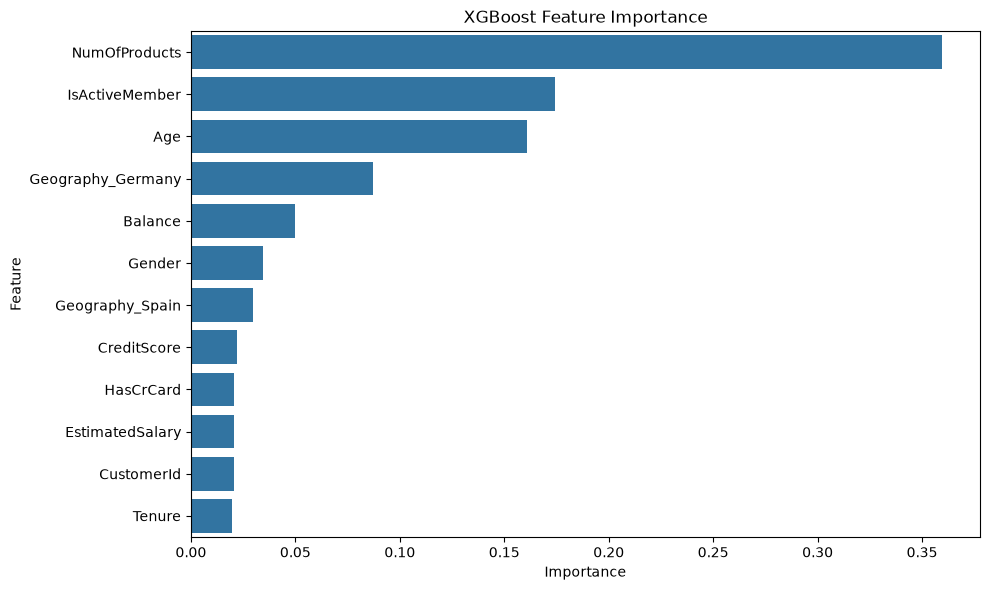

In [23]:
imp = classifiers.feature_importance(xgb_model, features.FEATURES)
plt.figure(figsize=(10, 6))
sns.barplot(data=imp, x='Importance', y='Feature')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

### CatBoost

Requires `catboost` (see `requirements-extra.txt`).

In [24]:
cat_model, cat_best_params = classifiers.train_catboost(X_train_scaled, y_train)
cat_result = classifiers.evaluate('CatBoost', y_test, cat_model.predict(X_test_scaled))
print('Best params:', cat_best_params)
print(cat_result.classification_report)
print(f'Accuracy: {cat_result.accuracy:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'depth': 6, 'iterations': 100, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.76      0.49      0.60       393

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

Accuracy: 0.8705


### LightGBM

Requires `lightgbm` (see `requirements-extra.txt`).

In [25]:
lgb_model, lgb_best_params = classifiers.train_lightgbm(X_train_scaled, y_train)
lgb_result = classifiers.evaluate('LightGBM', y_test, lgb_model.predict(X_test_scaled))
print('Best params:', lgb_best_params)
print(lgb_result.classification_report)
print(f'Accuracy: {lgb_result.accuracy:.4f}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[LightGBM] [Info] Number of positive: 1645, number of negative: 6355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1118
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205625 -> initscore=-1.351502
[LightGBM] [Info] Start training from score -1.351502
Best params: {'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.78      0.44      0.56       393

    accuracy                           0.87      2000
   macro avg       0.83      0.70      0.74      2000


### Model comparison

In [26]:
summary = pd.DataFrame(
    [
        {'Model': r.model_name, 'Accuracy': r.accuracy}
        for r in [rf_result, logr_result, svm_result, knn_result, gbm_result, xgb_result, cat_result, lgb_result]
    ]
).sort_values('Accuracy', ascending=False).reset_index(drop=True)
summary

,Model,Accuracy
0,CatBoost,0.8705
1,RandomForest,0.8665
2,LightGBM,0.8655
3,XGBoost,0.8645
4,GBM,0.8645
5,KNN,0.8290
6,LogisticRegression,0.8105
7,SVM,0.8035


## Survival analysis

`duration_col` (`Tenure`) must stay in real, unscaled units, so the Cox model is fit on the encoded-but-unscaled features, not `X_train_scaled`.

### Cox Proportional Hazards

In [27]:
cph = survival.fit_cox_model(X, y)
cph.print_summary()

AttributeError: The '.style' accessor requires jinja2

<lifelines.CoxPHFitter: fitted with 10000 total observations, 7962 right-censored observations>
             duration col = 'Tenure'
                event col = 'Exited'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 2038
   partial log-likelihood = -16488.68
         time fit was run = 2026-07-26 19:58:38 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
CustomerId        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
CreditScore       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
Gender            -0.39      0.68      0.04           -0.47           -0.30                0.62                0.74
Age                0.05      1.05      0.00            0.04            0.05                1.05                1.05
Balance            0.00      1.00      0.00            0.00            0.00                1.00                1.00
NumOfProducts     -0.07      0.94      0.04           -0.14            0.01                0.87                1.01
HasCrCard         -0.06      0.94      0.05           -0.16            0.03                0.85                1.03
IsActiveMember    -0.74      0.48      0.05           -0.83           -0.65                0.44                0.52
EstimatedSalary    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Geography_Germany  0.49      1.63      0.05            0.38            0.59                1.46                1.81
Geography_Spain    0.05      1.05      0.06           -0.07            0.17                0.93                1.18

                   cmp to      z      p  -log2(p)
covariate                                        
CustomerId           0.00  -0.82   0.41      1.27
CreditScore          0.00  -2.20   0.03      5.18
Gender               0.00  -8.62 <0.005     57.01
Age                  0.00  26.75 <0.005    521.36
Balance              0.00   4.78 <0.005     19.13
NumOfProducts        0.00  -1.69   0.09      3.46
HasCrCard            0.00  -1.31   0.19      2.40
IsActiveMember       0.00 -15.57 <0.005    179.08
EstimatedSalary      0.00   0.03   0.98      0.04
Geography_Germany    0.00   8.97 <0.005     61.50
Geography_Spain      0.00   0.80   0.42      1.24
---
Concordance = 0.72
Partial AIC = 32999.36
log-likelihood ratio test = 1157.15 on 11 df
-log2(p) of ll-ratio test = 799.11

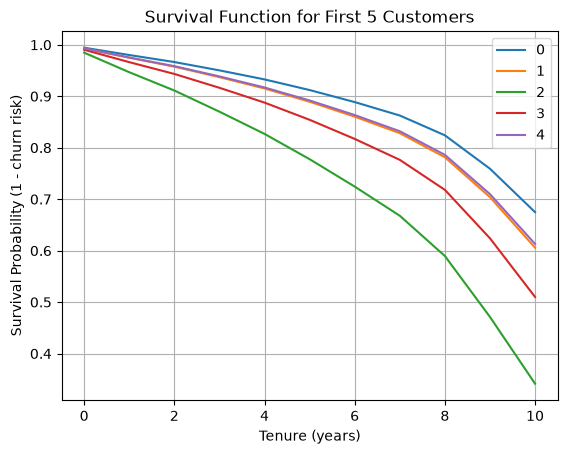

In [28]:
sample = X.join(y).iloc[:5]
surv_funcs = cph.predict_survival_function(sample.drop(columns=['Exited']))
surv_funcs.plot()
plt.title('Survival Function for First 5 Customers')
plt.xlabel('Tenure (years)')
plt.ylabel('Survival Probability (1 - churn risk)')
plt.grid(True)
plt.show()